# 02 — Region names: a curated unit → region / sub-region lookup (draft for vetting)

Second notebook of the **communities** analysis. **Zero solves, read-only on every input.** It writes one
table, `spec/region_lookup.csv`, and one figure, `figures/region_lookup_map.png`.

**Why.** Package spec v1.12 decision (e) (Ethan, 2026-09-17): every priority cluster in the director package
is labelled **"Cluster N (Region, Sub-region)"**. The region words come from the bear-coexistence communities
layer — a tessellation of Y2Y into 108 Canadian census divisions / US counties — through a curated lookup
*unit → region / sub-region*, because the shipped layer has no region column (report-back §4: the regional-
district names work in British Columbia, Alberta's divisions are numbered, the north is one 297,000 km² Yukon
unit plus NT "Region N", and the US south is too fine — one cluster spans nine counties).

**What this notebook does.** It reads notebook 01's audit table (the *corrected* containing province/state,
`ne_state`, not the shipped suffix — 21 units carry the wrong one) and the polygons, computes each unit's
centroid and area, and builds the lookup from **one explicit Python dict written in this notebook** (unit name +
admin-1 → region, sub-region, basis, note), so the curation is visible in code and diff-able. A check cell
proves 108 rows / no empties and lists the distinct region words with unit counts and area; an optional cell
overlays the 12 v3.1 deck picks to show what label each would get; the map colours units by region word.

**Ethan vets the words.** Nothing here is registered in `config`, nothing enters the optimizer, and
`director_core.placeholder_name` is untouched — the plug-in (a `region` column beside it on T-D1 / `picks.csv`)
is a later step once the words are agreed (report-back D-C3). Rows whose word is a judgement call carry
`VET:` in `note`.

**Naming convention (binding):** refer to things by what they are, codes in parentheses — "Dehcho Region
(Region 4)", "Division No. 15 — Banff, Jasper (principal places)", never the bare code.

**Columns of `region_lookup.csv`:** `fid, MappingUnit, name, admin1 (= ne_state), region, subregion, basis, note`.
`basis` ∈ {admin name, landscape name, gazetteer (north), principal places (AB)} says how the region word was
chosen. `note` flags the 21 corrected suffixes, the 4 name-collision units (and their 4 namesakes), the boundary
slivers, and every judgement call.

In [1]:
# ---- Setup: repo root, shared config, paths --------------------------------------------------
import sys, os, pathlib, importlib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config
importlib.reload(config)

HERE = ROOT / "analyses" / "communities"
SPEC, FIGS, AUDIT = HERE / "spec", HERE / "figures", HERE / "audit"
for _d in (SPEC, FIGS):
    _d.mkdir(parents=True, exist_ok=True)

UNITS_CSV = AUDIT / "bear_coexistence_units.csv"                                    # notebook 01's audit table (read-only)
GPKG = config.INPUT_DIR / "bear_coexistence" / "CoexistenceGroup_CDCounty_SpatJoin" / "CoexistenceGroup_CDCounty_Join.gpkg"
ADMIN_LINES = config.INPUT_DIR / "basemap" / "ne_10m_admin_1_states_provinces_lines.shp"   # map context only
Y2Y = config.INPUT_DIR / "y2y_boundary" / "y2y_region_boundary_2013.gpkg"                   # map context only
LOOKUP_CSV = SPEC / "region_lookup.csv"                                                       # THE output
MAP_PNG = FIGS / "region_lookup_map.png"
CRS = config.TARGET_CRS                                                                       # ESRI:102008

pd.set_option("display.width", 250); pd.set_option("display.max_columns", None); pd.set_option("display.max_rows", 130)
pd.set_option("display.max_colwidth", 120)
print(f"audit table : {UNITS_CSV.relative_to(ROOT)}")
print(f"polygons    : {GPKG.relative_to(ROOT)}")
print(f"writes      : {LOOKUP_CSV.relative_to(ROOT)}  |  {MAP_PNG.relative_to(ROOT)}")
print(f"work CRS    : {CRS}")

audit table : analyses/communities/audit/bear_coexistence_units.csv
polygons    : input_data/bear_coexistence/CoexistenceGroup_CDCounty_SpatJoin/CoexistenceGroup_CDCounty_Join.gpkg
writes      : analyses/communities/spec/region_lookup.csv  |  analyses/communities/figures/region_lookup_map.png
work CRS    : ESRI:102008


## 1 · Read the units: audit table + polygons, centroid and area

The join key is `fid` (the polygon's row index, as notebook 01 wrote it) and it is cross-checked on
`MappingUnit`. `admin1` is the audit table's `ne_state` — the province/state whose Natural Earth polygon
contains the unit — never the shipped suffix. Centroids are computed in the project CRS and reported as
lat/lon; area is re-measured and compared with the audit table's `area_km2`.

In [2]:
audit = pd.read_csv(UNITS_CSV)
poly = gpd.read_file(GPKG)
poly["fid"] = poly.index.astype(int)
assert len(audit) == len(poly) == 108, (len(audit), len(poly))

units = poly[["fid", "MappingUnit", "geometry"]].merge(
    audit[["fid", "MappingUnit", "country", "name", "label_state", "ne_state", "state_label_ok", "name_collision",
           "n_groups", "area_km2", "n_parts"]],
    on=["fid", "MappingUnit"], how="inner", validate="one_to_one")
assert len(units) == 108, "fid/MappingUnit join lost rows -- the audit table and the gpkg disagree"
units = gpd.GeoDataFrame(units, geometry="geometry", crs=poly.crs).rename(columns={"ne_state": "admin1"})

# centroid (in the equal-area CRS) reported as lat/lon; area re-measured against the audit table
u_eq = units.to_crs(CRS)
cen = u_eq.geometry.centroid.to_crs("EPSG:4326")
units["lat"] = cen.y.round(2).values
units["lon"] = cen.x.round(2).values
units["area_km2_check"] = (u_eq.geometry.area / 1e6).round(2).values
_d = (units["area_km2_check"] - units["area_km2"]).abs().max()
assert _d < 0.5, f"re-measured area disagrees with the audit table by {_d:.2f} km2"

print(f"{len(units)} units | admin-1 counts (corrected): {units['admin1'].value_counts().to_dict()}")
print(f"suffix wrong on {int((~units['state_label_ok']).sum())} units | name collisions flagged on {int(units['name_collision'].sum())} rows "
      f"(4 copied-count units + their 4 namesakes)")
print(f"area: min {units['area_km2'].min():,.2f}  median {units['area_km2'].median():,.0f}  max {units['area_km2'].max():,.0f} km2  "
      f"| max |re-measured - audit| = {_d:.2f} km2")
units[["fid", "name", "admin1", "label_state", "state_label_ok", "name_collision", "n_groups", "area_km2", "lat", "lon"]].head(8)

108 units | admin-1 counts (corrected): {'Idaho': 33, 'Montana': 28, 'British Columbia': 14, 'Alberta': 8, 'Washington': 8, 'Wyoming': 7, 'Oregon': 6, 'Northwest Territories': 3, 'Yukon': 1}
suffix wrong on 21 units | name collisions flagged on 8 rows (4 copied-count units + their 4 namesakes)
area: min 0.02  median 3,874  max 296,959 km2  | max |re-measured - audit| = 0.00 km2


,fid,name,admin1,label_state,state_label_ok,name_collision,n_groups,area_km2,lat,lon
0,0,Division No. 3,Alberta,Alberta,True,False,2.0,6641.31,49.57,-113.95
1,1,Division No. 6,Alberta,Alberta,True,False,2.0,2097.12,51.04,-114.54
2,2,Division No. 9,Alberta,Alberta,True,False,1.0,14845.62,52.25,-115.87
3,3,Division No. 11,Alberta,Alberta,True,False,NaN,191.51,53.02,-115.55
4,4,Division No. 14,Alberta,Alberta,True,False,NaN,16843.36,53.39,-117.69
5,5,Division No. 15,Alberta,Alberta,True,False,3.0,28569.79,51.74,-116.33
6,6,Division No. 18,Alberta,Alberta,True,False,NaN,16673.75,54.35,-118.86
7,7,Division No. 19,Alberta,Alberta,True,False,NaN,1681.61,55.13,-119.84


## 2 · The curated lookup (the thing to vet)

One dict, keyed by **(unit name, admin-1)** — the pair is unique across the 108 units, the bare name is not
(Madison, Teton, Lincoln, Park, Fremont, Jefferson each occur twice). Each value is
`(region, subregion, basis, note)`. Rules used:

- **`region`** = the coarse word a Y2Y director would recognise; conventional landscape / regional names; set
  kept small (27 distinct words over 108 units). Where the administrative name *is* the regional name
  (Kootenays, Peace, Stikine, Northern Rockies, Cariboo, Okanagan–Boundary, Columbia) `basis = "admin name"`;
  where a county or district name says nothing about the landscape (every US county; Bulkley-Nechako →
  Omineca; Thompson-Nicola → the Columbia Mountains) `basis = "landscape name"`.
- **Alberta**: divisions are numbered, so the sub-region carries the 2021 principal places
  (`basis = "principal places (AB)"`). The StatCan numbering used: No. 3 = Pincher Creek / Cardston /
  Waterton; No. 6 = Calgary region (only its foothills strip is inside Y2Y); No. 9 = Clearwater County (Rocky
  Mountain House, Nordegg); No. 11 = Edmonton region (a Brazeau County sliver); **No. 14 = Yellowhead County
  (Hinton, Edson) + Willmore Wilderness; No. 15 = the mountain-parks strip (Crowsnest Pass, Kananaskis, Canmore,
  Banff, Jasper)**; No. 18 = MD of Greenview (Grande Cache, Kakwa); No. 19 = Grande Prairie. The polygon
  geometry agrees: No. 14's centroid (53.4°N 117.7°W) sits on Hinton; No. 15 runs 49.1–54.0°N, Crowsnest Pass
  to Jasper's north boundary; No. 15's area (28,570 km²) matches the parks strip *without* Willmore.
- **The north** cannot be named from the file (one Yukon unit; NT "Region N"), so the words are a gazetteer
  by geography (`basis = "gazetteer (north)"`), verified below against the polygons: Region 1 = Inuvik Region
  (Peel Plateau / Richardson Mountains), Region 2 = Sahtú (Mackenzie Mountains), Region 4 = Dehcho (Nahanni).
- **Split units** (one county straddling two regions) are placed by the larger conservation-relevant share and
  say so in `note` with `VET:`; **boundary slivers** (< 200 km²) inherit their neighbour's word and are flagged.
- The 21 corrected suffixes and the 8 collision rows get their notes **programmatically** from the audit
  flags, so they cannot drift from notebook 01.

In [3]:
# region words, kept to a small set; the same string must be reused exactly (the check cell counts distinct words)
KOOT, OKB, COLM, CARB, ROBS, OMIN, STIK, NRBC, PEACE = (
    "Kootenays", "Okanagan–Boundary", "Columbia Mountains", "Cariboo", "Robson Valley / Upper Fraser",
    "Omineca", "Stikine", "Northern Rockies (BC)", "Peace region")
CROWN, BOWK, CABF, ABRK, KAKWA = (
    "Crown of the Continent", "Bow Valley / Kananaskis", "Central Alberta foothills", "Alberta Rockies (Banff–Jasper)",
    "Kakwa / Grande Cache")
YUKON, PEEL, SAHTU, DEHCHO = "Yukon", "Mackenzie Delta / Peel", "Sahtú", "Dehcho / Nahanni"
GYE, HIDIV, CIDA, WCIDA, CMONT, CABPUR, PANH, BLUE, SEIDA = (
    "Greater Yellowstone", "High Divide", "Central Idaho / Salmon–Bitterroot", "West-central Idaho (Boise–Payette)",
    "Central Montana island ranges", "Selkirk–Cabinet / Purcell (US)", "Idaho Panhandle / Clearwater",
    "Blue Mountains", "Southeast Idaho (Caribou–Bear River)")
ADMIN, LAND, GAZ, PP = "admin name", "landscape name", "gazetteer (north)", "principal places (AB)"
AB, BC, NT, YT, ID, MT, OR, WA, WY = ("Alberta", "British Columbia", "Northwest Territories", "Yukon", "Idaho", "Montana",
                                      "Oregon", "Washington", "Wyoming")

LOOKUP = {
    # ---- Alberta (numbered census divisions -> principal places) --------------------------------
    ("Division No. 3", AB): (CROWN, "Division No. 3 — Pincher Creek, Cardston, Fort Macleod, Claresholm; Waterton Lakes, Castle, Porcupine Hills (principal places)", PP,
                             "Alberta side of the Crown (Waterton–Castle); Crowsnest Pass itself is in Division No. 15"),
    ("Division No. 6", AB): (BOWK, "Division No. 6 — Calgary region; inside Y2Y only the foothills strip west of Calgary: Cochrane, Bragg Creek, Diamond Valley, Sundre (principal places)", PP,
                             "VET: the Y2Y strip is the Kananaskis front / Calgary foothills, not the Bow Valley proper (Canmore–Banff are Division No. 15); alternative word 'Calgary foothills'"),
    ("Division No. 9", AB): (CABF, "Division No. 9 — Rocky Mountain House, Caroline, Nordegg; Clearwater County, Bighorn backcountry (principal places)", PP, ""),
    ("Division No. 11", AB): (CABF, "Division No. 11 — Edmonton region; inside Y2Y only a 192 km² sliver of Brazeau County west of Drayton Valley (principal places)", PP,
                              "boundary sliver (192 km²) folded into the neighbouring foothills word — VET only if a cluster ever lands here"),
    ("Division No. 14", AB): (CABF, "Division No. 14 — Hinton, Edson; Yellowhead County, Willmore Wilderness (principal places)", PP,
                              "VET: StatCan 2021 puts Hinton/Edson in No. 14 (Yellowhead County) and Jasper in No. 15 — the clip centroid (53.4°N 117.7°W) sits on Hinton; 'Yellowhead / Willmore' is the landscape alternative to the foothills word"),
    ("Division No. 15", AB): (ABRK, "Division No. 15 — the mountain-parks strip: Crowsnest Pass, Kananaskis, Canmore, Banff, Jasper (principal places)", PP,
                              "VET: one unit spans 49–54°N (Crowsnest Pass to Jasper), so a cluster inside it needs the park / valley named per cluster (Bow Valley, Kananaskis, Jasper)"),
    ("Division No. 18", AB): (KAKWA, "Division No. 18 — Grande Cache, Valleyview, Fox Creek; MD of Greenview, Kakwa Wildland (principal places)", PP,
                              "VET: could fold into 'Peace region' or 'Central Alberta foothills' to shorten the set; kept separate because Kakwa–Grande Cache is its own landscape"),
    ("Division No. 19", AB): (PEACE, "Division No. 19 — Grande Prairie, Beaverlodge, Hythe; inside Y2Y only the County of Grande Prairie's western edge at the BC border (principal places)", PP, ""),
    # ---- British Columbia (regional districts) ---------------------------------------------------
    ("East Kootenay", BC): (KOOT, "Regional District of East Kootenay (Cranbrook, Kimberley, Fernie, Invermere; Rocky Mountain Trench, Purcells east, Elk Valley)", ADMIN, ""),
    ("Central Kootenay", BC): (KOOT, "Regional District of Central Kootenay (Nelson, Castlegar, Creston, Nakusp; West Kootenay — Selkirks, Kootenay Lake, Arrow Lakes)", ADMIN, ""),
    ("Kootenay Boundary", BC): (OKB, "Regional District of Kootenay Boundary (Grand Forks, Christina Lake, Greenwood, Rossland–Trail; Boundary country, Granby)", ADMIN,
                                "VET: the Y2Y clip is mostly the Boundary country (Granby / Christina Lake), hence the Boundary word; Rossland–Trail would say 'West Kootenay'"),
    ("Thompson-Nicola", BC): (COLM, "Thompson-Nicola Regional District, eastern part inside Y2Y (Clearwater, Blue River; North Thompson valley, Wells Gray, Monashee / Cariboo Mountains)", LAND,
                              "VET: the district name (Thompson) does not describe the clip; 'North Thompson / Wells Gray' is the alternative if it should stand apart from the Columbia Mountains"),
    ("Central Okanagan", BC): (OKB, "Regional District of Central Okanagan (Kelowna); inside Y2Y only a 135 km² sliver east of Big White (Kettle River headwaters)", ADMIN, "boundary sliver (135 km²)"),
    ("North Okanagan", BC): (OKB, "Regional District of North Okanagan (Vernon, Lumby; inside Y2Y the Monashee west slope — Lumby, Cherryville, Mabel Lake)", ADMIN,
                             "VET: the clip is the Monashee slope, so 'Columbia Mountains' is the geographic alternative"),
    ("Columbia-Shuswap", BC): (COLM, "Columbia-Shuswap Regional District (Revelstoke, Golden; Selkirks, Monashees, Purcells north, Rogers Pass, Kinbasket)", ADMIN, ""),
    ("Cariboo", BC): (CARB, "Cariboo Regional District, eastern part inside Y2Y (Wells–Barkerville, Bowron Lake, Likely / Quesnel Lake, Horsefly; Cariboo Mountains)", ADMIN,
                      "VET: 'Cariboo–Chilcotin' would overreach — no Chilcotin land is inside Y2Y; the clip is the Cariboo Mountains flank"),
    ("Kitimat-Stikine", BC): (STIK, "Regional District of Kitimat-Stikine, eastern part inside Y2Y (upper Skeena / Kispiox, Klappan – Sacred Headwaters, Spatsizi, Iskut; Tahltan and Gitxsan territory)", ADMIN,
                              "Terrace / Kitimat (the district's towns) are outside Y2Y; 'Sacred Headwaters' is the landmark word for clusters here"),
    ("Bulkley-Nechako", BC): (OMIN, "Regional District of Bulkley-Nechako, eastern part inside Y2Y (Fort St. James north, Takla Landing, Germansen Landing, Manson Creek; Omineca Mountains, Babine)", LAND,
                              "VET: the district name (Bulkley / Nechako) describes valleys outside the clip; Omineca is the conventional name for the mountains inside it"),
    ("Fraser-Fort George", BC): (ROBS, "Regional District of Fraser-Fort George (Prince George, Mackenzie, McBride, Valemount; Robson Valley, Rocky Mountain Trench, McGregor Range)", LAND,
                                 "VET: one word for a 38,000 km² unit from Valemount to Mackenzie — 'Robson Valley' fits the south (Mount Robson clusters), 'McGregor / Mackenzie' the north"),
    ("Peace River", BC): (PEACE, "Peace River Regional District (Fort St. John, Dawson Creek, Chetwynd, Tumbler Ridge, Hudson's Hope; Peace River Break, Williston)", ADMIN, ""),
    ("Stikine", BC): (STIK, "Stikine Region (unincorporated: Dease Lake, Telegraph Creek, Good Hope Lake; Cassiar Mountains, Kechika — Tahltan and Kaska Dena territory, Dene Kʼéh Kusān)", ADMIN,
                      "VET: the Y2Y clip is largely Cassiar / Kechika (Kaska country) rather than the Stikine valley — 'Cassiar' is the alternative word"),
    ("Northern Rockies", BC): (NRBC, "Northern Rockies Regional Municipality (Fort Nelson; Muskwa–Kechika, Liard)", ADMIN, ""),
    # ---- The north (gazetteer by geography; verified against the polygons below) -----------------
    ("Yukon", YT): (YUKON, "eastern Yukon — Peel / Wind / Snake watersheds and Fishing Branch (north), Selwyn and Mackenzie Mountains flank, Ross River / Kaska Dena territory (south) (gazetteer)", GAZ,
                    "VET: ONE unit = the territory's whole Y2Y share (297,000 km², 58–69°N) — no unit-level sub-region can be right for every cluster; name per cluster by watershed (deck pick 11 → Peel watershed, east of Fishing Branch)"),
    ("Region 1", NT): (PEEL, "Inuvik Region (Region 1) — Peel Plateau and Richardson Mountains, Gwich'in Settlement Area (gazetteer)", GAZ,
                       "placement verified from the polygon: a 12,900 km² north–south strip along the Yukon border, 63.8–67.8°N (the NT side of the Peel watershed)"),
    ("Region 2", NT): (SAHTU, "Sahtú Region (Region 2) — Mackenzie Mountains west of Norman Wells / Tulita; Nááts'įhch'oh, Canol Heritage Trail (gazetteer)", GAZ,
                       "placement verified from the polygon: centroid 64.1°N 128.1°W, 61.9–66.9°N"),
    ("Region 4", NT): (DEHCHO, "Dehcho Region (Region 4) — Nahanni National Park Reserve, Fort Simpson / Fort Liard / Nahanni Butte, Liard and South Nahanni (gazetteer)", GAZ,
                       "placement verified from the polygon: centroid 62.0°N 124.8°W, 59.5–64.2°N; Virginia Falls (61.6°N 125.8°W) inside it"),
    # ---- Idaho ------------------------------------------------------------------------------------
    ("Ada County", ID): (WCIDA, "Ada County (Boise; a 50 km² sliver of the Boise foothills)", LAND, "boundary sliver (50 km²)"),
    ("Adams County", ID): (WCIDA, "Adams County (Council, New Meadows; Cuddy Mountains, Hells Canyon rim)", LAND, ""),
    ("Bear Lake County", ID): (SEIDA, "Bear Lake County (Paris, Montpelier; Bear River Range)", LAND, "VET: outside most Greater Yellowstone definitions; grouped with Caribou County"),
    ("Benewah County", ID): (PANH, "Benewah County (St. Maries; St. Joe River)", LAND, ""),
    ("Bingham County", ID): (SEIDA, "Bingham County (Blackfoot; a 173 km² sliver of the Blackfoot Mountains)", LAND, "boundary sliver (173 km²)"),
    ("Blaine County", ID): (CIDA, "Blaine County (Hailey; Ketchum – Sun Valley, Sawtooth NRA, Pioneer Mountains)", LAND, "VET: 'Sawtooth / Wood River' may deserve its own word (with Camas County)"),
    ("Boise County", ID): (WCIDA, "Boise County (Idaho City; Boise Mountains, Lowman, Sawtooth west)", LAND, ""),
    ("Bonner County", ID): (CABPUR, "Bonner County (Sandpoint; Selkirks, Cabinets, Lake Pend Oreille)", LAND, ""),
    ("Bonneville County", ID): (GYE, "Bonneville County (Idaho Falls; Swan Valley, Palisades, Caribou-Targhee NF)", LAND, ""),
    ("Boundary County", ID): (CABPUR, "Boundary County (Bonners Ferry; Selkirks, Purcells, Kootenai valley)", LAND, ""),
    ("Butte County", ID): (HIDIV, "Butte County (Arco; Lost River Range, Little Lost)", LAND, "VET: alternative 'Central Idaho / Salmon–Bitterroot'"),
    ("Camas County", ID): (CIDA, "Camas County (Fairfield; Soldier Mountains)", LAND, "VET: with Blaine County — 'Sawtooth / Wood River' alternative"),
    ("Canyon County", ID): (WCIDA, "Canyon County (Caldwell; a 0.02 km² clip sliver)", LAND, "clip sliver (0.02 km²) — ignore"),
    ("Caribou County", ID): (SEIDA, "Caribou County (Soda Springs; Caribou Range, Grays Lake)", LAND, "VET: alternative 'Greater Yellowstone' (the Caribou Range is its south-west edge)"),
    ("Clark County", ID): (HIDIV, "Clark County (Dubois; Centennial Mountains)", LAND, "the Centennials are the Greater Yellowstone – High Divide link; 'Greater Yellowstone' is the alternative"),
    ("Clearwater County", ID): (PANH, "Clearwater County (Orofino; North Fork Clearwater, Dworshak)", LAND, ""),
    ("Custer County", ID): (CIDA, "Custer County (Challis; Stanley, Sawtooths, Lost River Range, Salmon River)", LAND, ""),
    ("Elmore County", ID): (WCIDA, "Elmore County (Mountain Home; Boise Mountains south, Trinity Mountains)", LAND, ""),
    ("Fremont County", ID): (GYE, "Fremont County, Idaho (St. Anthony; Island Park, Ashton, Henrys Fork)", LAND, ""),
    ("Gem County", ID): (WCIDA, "Gem County (Emmett; West Mountains)", LAND, ""),
    ("Idaho County", ID): (CIDA, "Idaho County (Grangeville; Frank Church, Gospel Hump, Selway–Bitterroot, Hells Canyon)", LAND, ""),
    ("Jefferson County", ID): (GYE, "Jefferson County, Idaho (Rigby; a 42 km² sliver east of Ririe)", LAND, "boundary sliver (42 km²)"),
    ("Kootenai County", ID): (PANH, "Kootenai County (Coeur d'Alene; Coeur d'Alene Mountains)", LAND, ""),
    ("Latah County", ID): (PANH, "Latah County (Moscow; Palouse, Palouse Range)", LAND, "VET: Palouse farmland — thin conservation relevance"),
    ("Lemhi County", ID): (CIDA, "Lemhi County (Salmon; Lemhi Range, Beaverhead Mountains, Frank Church east)", LAND, "VET: the High Divide Collaborative counts Lemhi in; alternative 'High Divide'"),
    ("Lewis County", ID): (PANH, "Lewis County (Nezperce; Camas Prairie)", LAND, ""),
    ("Madison County", ID): (GYE, "Madison County, Idaho (Rexburg; Big Hole Mountains)", LAND, ""),
    ("Nez Perce County", ID): (PANH, "Nez Perce County (Lewiston; Craig Mountain, Hells Canyon north)", LAND, ""),
    ("Payette County", ID): (WCIDA, "Payette County (Payette)", LAND, ""),
    ("Shoshone County", ID): (PANH, "Shoshone County (Wallace; Silver Valley, St. Joe, Coeur d'Alene Mountains)", LAND, ""),
    ("Teton County", ID): (GYE, "Teton County, Idaho (Driggs; Teton Valley, Big Hole Mountains)", LAND, ""),
    ("Valley County", ID): (CIDA, "Valley County (Cascade; McCall, Frank Church west, Salmon River Mountains)", LAND, "VET: the west half (McCall / Cascade) is West-central Idaho — placed by the Frank Church share"),
    ("Washington County", ID): (WCIDA, "Washington County (Weiser; Hells Canyon south, Cuddy Mountains)", LAND, ""),
    # ---- Montana ----------------------------------------------------------------------------------
    ("Beaverhead County", MT): (HIDIV, "Beaverhead County (Dillon; Big Hole, Pioneer Mountains, Centennial Range)", LAND, ""),
    ("Broadwater County", MT): (CMONT, "Broadwater County (Townsend; Big Belt Mountains, Elkhorns)", LAND, "VET: alternative 'High Divide'"),
    ("Carbon County", MT): (GYE, "Carbon County (Red Lodge; Beartooths)", LAND, ""),
    ("Cascade County", MT): (CMONT, "Cascade County (Great Falls; inside Y2Y the Little Belt Mountains — Monarch, Neihart)", LAND, ""),
    ("Deer Lodge County", MT): (HIDIV, "Deer Lodge County (Anaconda; Anaconda–Pintler)", LAND, ""),
    ("Flathead County", MT): (CROWN, "Flathead County (Kalispell; Glacier NP west, Bob Marshall, Whitefish Range, North Fork Flathead)", LAND, ""),
    ("Gallatin County", MT): (GYE, "Gallatin County (Bozeman; Gallatin Range, Big Sky, Yellowstone north-west)", LAND, ""),
    ("Glacier County", MT): (CROWN, "Glacier County (Cut Bank; Glacier NP east, Blackfeet Nation)", LAND, ""),
    ("Granite County", MT): (HIDIV, "Granite County (Philipsburg; Flint Creek Range, Pintler)", LAND, ""),
    ("Jefferson County", MT): (HIDIV, "Jefferson County, Montana (Boulder; Elkhorns, Boulder Mountains)", LAND, ""),
    ("Judith Basin County", MT): (CMONT, "Judith Basin County (Stanford; Little Belts)", LAND, ""),
    ("Lake County", MT): (CROWN, "Lake County (Polson; Mission Mountains, Flathead Reservation)", LAND, ""),
    ("Lewis and Clark County", MT): (CROWN, "Lewis and Clark County (Helena; Rocky Mountain Front — Augusta, Scapegoat / Bob Marshall)", LAND, "VET: the south end (Helena, Big Belts / Elkhorns) is not Crown"),
    ("Lincoln County", MT): (CABPUR, "Lincoln County, Montana (Libby; Cabinets, Purcells, Yaak)", LAND, ""),
    ("Madison County", MT): (GYE, "Madison County, Montana (Virginia City; Madison Range, Gravelly Range, Tobacco Roots)", LAND, "VET: the west half (Gravelly, Centennial) is High Divide"),
    ("Meagher County", MT): (CMONT, "Meagher County (White Sulphur Springs; Castle Mountains, Little Belts, Big Belts)", LAND, ""),
    ("Mineral County", MT): (PANH, "Mineral County, Montana (Superior; St. Regis, Bitterroot Divide, Lolo NF)", LAND,
                             "VET: a Montana county under a Panhandle word — placed by geography (the Bitterroot Divide with Shoshone County); alternative 'Central Idaho / Salmon–Bitterroot'"),
    ("Missoula County", MT): (CROWN, "Missoula County (Missoula; Rattlesnake, Blackfoot, Seeley–Swan)", LAND, ""),
    ("Park County", MT): (GYE, "Park County, Montana (Livingston; Paradise Valley, Absaroka, Yellowstone north gateway)", LAND, ""),
    ("Pondera County", MT): (CROWN, "Pondera County (Conrad; Rocky Mountain Front)", LAND, ""),
    ("Powell County", MT): (CROWN, "Powell County (Deer Lodge; Blackfoot / Ovando, Scapegoat, Garnet Range)", LAND, "VET: split unit — Blackfoot / Scapegoat (Crown) north, Deer Lodge valley (High Divide) south"),
    ("Ravalli County", MT): (CIDA, "Ravalli County, Montana (Hamilton; Bitterroot Valley, Selway–Bitterroot, Sapphire Mountains)", LAND, "VET: a Montana county under the Salmon–Bitterroot word (the Montana side of the Selway–Bitterroot)"),
    ("Sanders County", MT): (CABPUR, "Sanders County, Montana (Thompson Falls; Cabinets south, Clark Fork)", LAND, ""),
    ("Silver Bow County", MT): (HIDIV, "Silver Bow County (Butte; Highland Mountains)", LAND, ""),
    ("Stillwater County", MT): (GYE, "Stillwater County (Columbus; Beartooth foothills)", LAND, ""),
    ("Sweet Grass County", MT): (GYE, "Sweet Grass County (Big Timber; Crazy Mountains, Absaroka north)", LAND, "VET: split unit — the Crazies are an island range (Central Montana word) rather than Greater Yellowstone"),
    ("Teton County", MT): (CROWN, "Teton County, Montana (Choteau; Rocky Mountain Front)", LAND, ""),
    ("Wheatland County", MT): (CMONT, "Wheatland County (Harlowton; Crazy Mountains east, Little Belts south)", LAND, ""),
    # ---- Oregon -----------------------------------------------------------------------------------
    ("Baker County", OR): (BLUE, "Baker County (Baker City; Elkhorn Mountains, Wallowas south)", LAND, ""),
    ("Grant County", OR): (BLUE, "Grant County, Oregon (Canyon City; a 25 km² sliver of the Blue Mountains)", LAND, "boundary sliver (25 km²)"),
    ("Malheur County", OR): (BLUE, "Malheur County (Vale; 491 km² on the Snake River near Huntington)", LAND, "VET: boundary piece on the Snake River, Blue Mountains only by adjacency"),
    ("Umatilla County", OR): (BLUE, "Umatilla County (Pendleton; Blue Mountains, Umatilla NF)", LAND, ""),
    ("Union County", OR): (BLUE, "Union County (La Grande; Grande Ronde valley, Wallowas west, Elkhorns)", LAND, ""),
    ("Wallowa County", OR): (BLUE, "Wallowa County (Enterprise; Wallowa Mountains, Hells Canyon)", LAND, ""),
    # ---- Washington -------------------------------------------------------------------------------
    ("Asotin County", WA): (BLUE, "Asotin County (Asotin; Blue Mountains, Snake River)", LAND, ""),
    ("Columbia County", WA): (BLUE, "Columbia County, Washington (Dayton; Blue Mountains)", LAND, ""),
    ("Ferry County", WA): (OKB, "Ferry County (Republic; Kettle Range — 290 km² on the US side of the Boundary country)", LAND, "VET: US side of the Boundary / Kettle River; alternative 'Selkirk–Cabinet / Purcell (US)'"),
    ("Garfield County", WA): (BLUE, "Garfield County, Washington (Pomeroy; Blue Mountains)", LAND, ""),
    ("Pend Oreille County", WA): (CABPUR, "Pend Oreille County (Newport; Selkirks, Pend Oreille River)", LAND, ""),
    ("Spokane County", WA): (PANH, "Spokane County (Spokane; Mount Spokane, the Idaho-border strip)", LAND, "VET: a Washington county under a Panhandle word — placed by geography (Mount Spokane adjoins the Coeur d'Alene Mountains)"),
    ("Stevens County", WA): (CABPUR, "Stevens County (Colville; Selkirk foothills east of Colville, Pend Oreille River)", LAND, ""),
    ("Walla Walla County", WA): (BLUE, "Walla Walla County (Walla Walla; a 140 km² sliver of the Blue Mountains foothills)", LAND, "boundary sliver (140 km²)"),
    # ---- Wyoming ----------------------------------------------------------------------------------
    ("Fremont County", WY): (GYE, "Fremont County, Wyoming (Lander; Wind River Range east, Dubois, Absaroka)", LAND, "VET: 'Wind River' is the alternative word for the Wyoming south-east (Fremont, Sublette, Sweetwater)"),
    ("Hot Springs County", WY): (GYE, "Hot Springs County (Thermopolis; Absaroka east, Owl Creek Mountains)", LAND, "eastern Greater Yellowstone fringe"),
    ("Lincoln County", WY): (GYE, "Lincoln County, Wyoming (Kemmerer; Star Valley, Salt River and Wyoming ranges)", LAND, ""),
    ("Park County", WY): (GYE, "Park County, Wyoming (Cody; Absaroka, Yellowstone east)", LAND, ""),
    ("Sublette County", WY): (GYE, "Sublette County (Pinedale; Wind River Range west, Wyoming Range, Upper Green)", LAND, "VET: 'Wind River / Upper Green' alternative"),
    ("Sweetwater County", WY): (GYE, "Sweetwater County (Green River; a 363 km² sliver at South Pass)", LAND, "boundary sliver (363 km²)"),
    ("Teton County", WY): (GYE, "Teton County, Wyoming (Jackson; Tetons, Grand Teton NP, Yellowstone south)", LAND, ""),
}
BASES = {ADMIN, LAND, GAZ, PP}
assert all(v[2] in BASES for v in LOOKUP.values())
print(f"{len(LOOKUP)} curated entries | {len({v[0] for v in LOOKUP.values()})} distinct region words")

108 curated entries | 27 distinct region words


In [4]:
# ---- Build the lookup table: curated words + programmatic notes from the audit flags ----------------
keys = list(zip(units["name"], units["admin1"]))
missing = [k for k in keys if k not in LOOKUP]
extra = [k for k in LOOKUP if k not in set(keys)]
assert not missing and not extra, f"lookup/unit mismatch -- missing {missing}, extra {extra}"
assert len(set(keys)) == 108, "(name, admin1) is not unique -- the dict key would be ambiguous"

rows = []
for r in units.itertuples(index=False):
    region, subregion, basis, vet = LOOKUP[(r.name, r.admin1)]
    notes = []
    if not r.state_label_ok:
        notes.append(f"suffix corrected: shipped {r.label_state}, polygon in {r.admin1}")
    if r.name_collision:
        others = units[(units["name"] == r.name) & (units["admin1"] != r.admin1)]
        for o in others.itertuples(index=False):
            if not r.state_label_ok:      # this row is the mislabelled twin: its count is the namesake's
                notes.append(f"NAME COLLISION: n_groups {r.n_groups:g} equals {o.name}, {o.admin1} (fid {o.fid}) -- treated as a copied count / false positive (report-back §2), set aside")
            else:                          # this row is the namesake whose count was copied
                notes.append(f"name collision: {o.name}, {o.admin1} (fid {o.fid}) shipped with this unit's suffix and count")
    if vet:
        notes.append(vet)
    rows.append(dict(fid=int(r.fid), MappingUnit=r.MappingUnit, name=r.name, admin1=r.admin1, region=region,
                     subregion=subregion, basis=basis, note="; ".join(notes)))
lookup = pd.DataFrame(rows, columns=["fid", "MappingUnit", "name", "admin1", "region", "subregion", "basis", "note"])
lookup.to_csv(LOOKUP_CSV, index=False, encoding="utf-8")
print(f"wrote {LOOKUP_CSV.relative_to(ROOT)}  ({len(lookup)} rows, columns {list(lookup.columns)})")

# ---- The north: verify the gazetteer placements against the polygons, not the file's labels -------
u_ll = units.set_index(["name", "admin1"])
u_eq_i = u_eq.set_index(["name", "admin1"])
from shapely.geometry import Point
def _inside(key, lat, lon):
    pt = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326").to_crs(CRS).iloc[0]
    return bool(u_eq_i.loc[key, "geometry"].contains(pt))
north_checks = [  # (unit, expected centroid box lat/lon, landmark inside?)
    (("Region 1", NT), (63.0, 68.0, -134.5, -131.0), None),
    (("Region 2", NT), (62.0, 67.0, -130.0, -125.0), ("Nááts'įhch'oh NPR (upper South Nahanni)", 62.9, -128.6)),
    (("Region 4", NT), (59.0, 65.0, -128.0, -121.0), ("Virginia Falls, Nahanni NPR", 61.61, -125.78)),
    (("Yukon", YT),    (60.0, 67.0, -136.0, -130.0), ("Ross River", 61.98, -132.45)),
]
print("\nNorthern gazetteer -- polygon centroids vs the expected boxes, plus a landmark test where one is known:")
for key, (la0, la1, lo0, lo1), lm in north_checks:
    lat, lon = float(u_ll.loc[key, "lat"]), float(u_ll.loc[key, "lon"])
    ok = la0 <= lat <= la1 and lo0 <= lon <= lo1
    assert ok, f"{key}: centroid {lat},{lon} outside the expected box -- the gazetteer word would be wrong"
    s = f"  {key[0]:9s} ({LOOKUP[key][0]:24s}) centroid {lat:6.2f}N {abs(lon):6.2f}W  box OK"
    if lm:
        s += f" | {lm[0]} inside: {_inside(key, lm[1], lm[2])}"
    print(s)

wrote analyses/communities/spec/region_lookup.csv  (108 rows, columns ['fid', 'MappingUnit', 'name', 'admin1', 'region', 'subregion', 'basis', 'note'])

Northern gazetteer -- polygon centroids vs the expected boxes, plus a landmark test where one is known:
  Region 1  (Mackenzie Delta / Peel  ) centroid  65.39N 132.03W  box OK
  Region 2  (Sahtú                   ) centroid  64.09N 128.11W  box OK | Nááts'įhch'oh NPR (upper South Nahanni) inside: True
  Region 4  (Dehcho / Nahanni        ) centroid  62.01N 124.82W  box OK | Virginia Falls, Nahanni NPR inside: True
  Yukon     (Yukon                   ) centroid  63.39N 133.42W  box OK | Ross River inside: True


## 3 · Checks: 108 rows, no empties, the distinct region words

The check is hard (asserts): every row has a non-empty `region` and `subregion`, `basis` is one of the four
allowed values, `admin1` equals the audit table's corrected province/state, and the CSV round-trips.
The word table below is the thing to read: unit count, units with groups, and area (km² inside Y2Y) per word.

In [5]:
chk = pd.read_csv(LOOKUP_CSV, keep_default_na=False)
assert list(chk.columns) == ["fid", "MappingUnit", "name", "admin1", "region", "subregion", "basis", "note"], list(chk.columns)
assert len(chk) == 108 and chk["fid"].is_unique
for c in ["region", "subregion", "basis", "admin1", "name", "MappingUnit"]:
    assert (chk[c].str.strip() != "").all(), f"empty {c} in the lookup"
assert set(chk["basis"]) <= BASES, set(chk["basis"]) - BASES
assert (chk["admin1"].values == audit.set_index("fid").loc[chk["fid"], "ne_state"].values).all()
assert not chk["MappingUnit"].str.contains("_", regex=False).isna().any()
n_flag = int(chk["note"].str.startswith("suffix corrected").sum()); n_coll = int(chk["note"].str.contains("COLLISION").sum())
assert n_flag == 21 and n_coll == 4, (n_flag, n_coll)
n_vet = int(chk["note"].str.contains("VET:").sum())

w = (chk.merge(units[["fid", "area_km2", "n_groups", "country"]], on="fid")
        .groupby("region")
        .agg(units=("fid", "size"), with_groups=("n_groups", lambda s: int(s.notna().sum())),
             km2=("area_km2", "sum"), admin1=("admin1", lambda s: ", ".join(sorted(set(s)))),
             basis=("basis", lambda s: " / ".join(sorted(set(s)))))
        .sort_values("km2", ascending=False))
w["km2"] = w["km2"].round(0).astype(int)
print(f"108 rows OK | {chk['region'].nunique()} distinct region words | 21 corrected suffixes flagged | 4 copied-count collisions flagged | "
      f"{n_vet} rows marked VET: | basis counts: {chk['basis'].value_counts().to_dict()}")
print(f"total area {w['km2'].sum():,} km2 (audit table sum {units['area_km2'].sum():,.0f})")
w

108 rows OK | 27 distinct region words | 21 corrected suffixes flagged | 4 copied-count collisions flagged | 32 rows marked VET: | basis counts: {'landscape name': 85, 'admin name': 11, 'principal places (AB)': 8, 'gazetteer (north)': 4}
total area 1,369,832 km2 (audit table sum 1,369,830)


,units,with_groups,km2,admin1,basis
region,,,,,
Yukon,1,0,296959,Yukon,gazetteer (north)
Stikine,2,0,121414,British Columbia,admin name
Peace region,2,0,101587,"Alberta, British Columbia",admin name / principal places (AB)
Greater Yellowstone,18,9,96428,"Idaho, Montana, Wyoming",landscape name
Sahtú,1,0,80819,Northwest Territories,gazetteer (north)
Dehcho / Nahanni,1,0,78680,Northwest Territories,gazetteer (north)
Central Idaho / Salmon–Bitterroot,7,0,68287,"Idaho, Montana",landscape name
Crown of the Continent,9,9,54704,"Alberta, Montana",landscape name / principal places (AB)
Kootenays,2,2,50994,British Columbia,admin name


## 4 · Sanity overlay: what the 12 v3.1 deck picks would be called (optional, read-only)

Uses `analyses/y2y/director_package/tables/picks.csv` + `geotiffs/clusters.gpkg` if present (skips otherwise).
Rule from report-back D-C3 as drafted: **region = the largest area share; secondaries listed when ≥ 15 %**;
the sub-region shown is the largest-share unit's. This is a preview of the label form, not the plug-in —
`director_core.placeholder_name` is untouched.

In [6]:
PICKS = ROOT / "analyses" / "y2y" / "director_package" / "tables" / "picks.csv"
CLUSTERS = ROOT / "analyses" / "y2y" / "director_package" / "geotiffs" / "clusters.gpkg"
u_ov = u_eq.merge(lookup[["fid", "region", "subregion"]], on="fid")
if PICKS.exists() and CLUSTERS.exists():
    picks = pd.read_csv(PICKS)
    picks = picks[picks["number"].astype(str).str.fullmatch(r"\d+")].copy()
    picks["number"] = picks["number"].astype(int)
    layer_for = {"ensemble": "act1", "s1": "act2_s1", "s2": "act2_s2", "s3": "act2_s3", "s4": "act2_s4"}
    layers = {ly: gpd.read_file(CLUSTERS, layer=ly).to_crs(CRS) for ly in set(layer_for.values())}
    out = []
    for p in picks.sort_values("number").itertuples(index=False):
        cids = [int(c) for c in str(p.cids).split(";")]
        L = layers[layer_for[p.key]]
        geom = L[L["cid"].isin(cids)].geometry.union_all()
        inter = u_ov.geometry.intersection(geom).area / 1e6
        share = (inter / inter.sum()).rename("share")
        by_unit = pd.concat([u_ov[["name", "admin1", "region", "subregion"]], share], axis=1).query("share > 0").sort_values("share", ascending=False)
        by_region = by_unit.groupby("region")["share"].sum().sort_values(ascending=False)
        primary = by_region.index[0]
        secondaries = [f"{r} {s:.0%}" for r, s in by_region.iloc[1:].items() if s >= 0.15]
        top = by_unit.iloc[0]
        label = f"Cluster {p.number} ({primary}, {top['name']}{', ' + top['admin1'] if top['admin1'] in ('Idaho','Montana','Wyoming','Oregon','Washington') else ''})"
        out.append(dict(pick=p.number, act=p.act, km2=int(p.km2), placeholder=p.name, region=primary, region_share=round(float(by_region.iloc[0]), 2),
                        secondaries="; ".join(secondaries) or "-", n_units=int((by_unit["share"] >= 0.01).sum()), label_preview=label))
    ov = pd.DataFrame(out)
    display(ov)
else:
    print("picks.csv / clusters.gpkg not found -- overlay skipped (optional)")

,pick,act,km2,placeholder,region,region_share,secondaries,n_units,label_preview
0,1,Act 1,11490,SW of Tahltan - Sacred Headwaters (Klappan) (56.8°N 129.3°W),Stikine,0.97,-,3,"Cluster 1 (Stikine, Kitimat-Stikine)"
1,2,Act 1,12105,Purcell Wilderness Conservancy Park vicinity (50.1°N 116.4°W),Kootenays,0.61,Columbia Mountains 29%,4,"Cluster 2 (Kootenays, East Kootenay)"
2,3,Act 1,2507,N of Granby Park (49.9°N 118.7°W),Columbia Mountains,0.44,Okanagan–Boundary 40%,5,"Cluster 3 (Columbia Mountains, Thompson-Nicola)"
3,4,Act 1,5229,NW of Frank Church River Of No Return Wilderness (45.2°N 115.6°W),Central Idaho / Salmon–Bitterroot,0.81,Blue Mountains 17%,9,"Cluster 4 (Central Idaho / Salmon–Bitterroot, Idaho County, Idaho)"
4,5,Act 2,12198,Tahltan - Sacred Headwaters (Klappan) vicinity (57.0°N 128.9°W),Stikine,0.94,-,4,"Cluster 5 (Stikine, Kitimat-Stikine)"
5,6,Act 2,8680,Purcell Wilderness Conservancy Park vicinity (49.9°N 116.3°W),Kootenays,0.66,Columbia Mountains 23%,6,"Cluster 6 (Kootenays, East Kootenay)"
6,7,Act 2,2677,NW of Wilps Gwininitxw (56.6°N 128.3°W),Stikine,0.95,-,3,"Cluster 7 (Stikine, Kitimat-Stikine)"
7,8,Act 2,1428,S of Mount Robson Park (52.5°N 118.6°W),Kootenays,0.53,Columbia Mountains 33%,4,"Cluster 8 (Kootenays, East Kootenay)"
8,9,Act 2,529,S of Purcell Wilderness Conservancy Park (49.6°N 116.4°W),Kootenays,1.00,-,2,"Cluster 9 (Kootenays, East Kootenay)"
9,10,Act 2,157,NE of Gospel Hump Wilderness (45.8°N 115.5°W),Central Idaho / Salmon–Bitterroot,1.00,-,1,"Cluster 10 (Central Idaho / Salmon–Bitterroot, Idaho County, Idaho)"


## 5 · Map: units coloured by region word

Twenty-seven classes exceed what any categorical palette can keep distinct, so **identity is carried by the
labels and the legend, not by colour** — colour is a reading aid (seven base hues × lightness steps, assigned
in a south-to-north chain so latitude-neighbours differ in hue). Each region carries a **number** at its
label point (full names would collide in the BC–Alberta–Montana band); the legend lists the numbers north → south
with the word, unit count and area. Thin white lines = unit borders; dark lines = region borders; grey dashes
= province/state borders; the Y2Y boundary is the frame. Units ≥ 25,000 km² also carry their unit name in
small italics.

wrote analyses/communities/figures/region_lookup_map.png


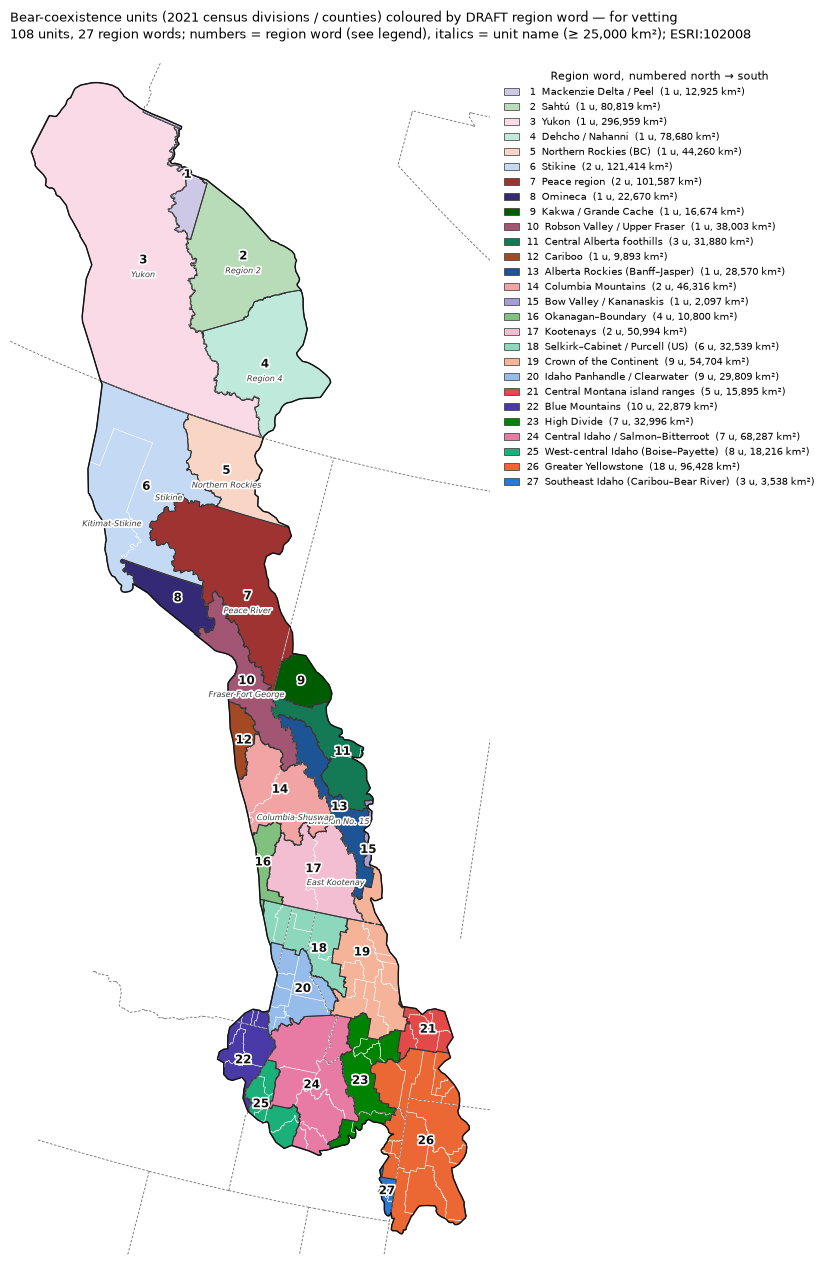

In [7]:
BASE_HUES = ["#2a78d6", "#eb6834", "#1baf7a", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]   # dataviz reference categorical slots (yellow dropped: too light on white)
def _mix(hexc, f):  # f>0 toward white, f<0 toward black
    r, g, b = mcolors.to_rgb(hexc)
    t = (1.0, 1.0, 1.0) if f > 0 else (0.0, 0.0, 0.0)
    a = abs(f)
    return tuple(c * (1 - a) + tc * a for c, tc in zip((r, g, b), t))
TINTS = [0.0, 0.5, -0.3, 0.72]

um = u_eq.merge(lookup[["fid", "region", "subregion"]], on="fid")
um["_lat"] = units["lat"].values
order = (um.assign(w=um["area_km2"] * um["_lat"]).groupby("region").agg(w=("w", "sum"), a=("area_km2", "sum"))
           .eval("lat = w / a").sort_values("lat").index.tolist())          # south -> north chain
REGION_COLOR = {r: _mix(BASE_HUES[i % len(BASE_HUES)], TINTS[i // len(BASE_HUES)]) for i, r in enumerate(order)}

regs = um.dissolve(by="region", aggfunc={"area_km2": "sum", "fid": "size"}).rename(columns={"fid": "units"})
def _label_point(geom):
    g = max(geom.geoms, key=lambda p: p.area) if geom.geom_type == "MultiPolygon" else geom
    return g.representative_point()
regs["pt"] = regs.geometry.apply(_label_point)

admin_lines = gpd.read_file(ADMIN_LINES).to_crs(CRS) if ADMIN_LINES.exists() else None
y2y = gpd.read_file(Y2Y).to_crs(CRS) if Y2Y.exists() else None
minx, miny, maxx, maxy = um.total_bounds
pad = 60_000

fig, ax = plt.subplots(figsize=(11, 15.5))
um.plot(ax=ax, color=[REGION_COLOR[r] for r in um["region"]], edgecolor="white", linewidth=0.35, zorder=2)
regs.boundary.plot(ax=ax, color="#333333", linewidth=0.7, zorder=3)
if admin_lines is not None:
    admin_lines.cx[minx - pad:maxx + pad, miny - pad:maxy + pad].plot(ax=ax, color="#6b6b6b", linewidth=0.6, linestyle=(0, (3, 2)), zorder=4)
if y2y is not None:
    y2y.boundary.plot(ax=ax, color="#111111", linewidth=1.0, zorder=5)
halo = [pe.withStroke(linewidth=2.5, foreground="white")]
NUM = {r: i + 1 for i, r in enumerate(order[::-1])}                          # 1 = northernmost word
for r, row in regs.iterrows():
    ax.annotate(str(NUM[r]), (row["pt"].x, row["pt"].y), ha="center", va="center", fontsize=8.5, fontweight="bold", color="#111111",
                path_effects=halo, zorder=7)
big = um[um["area_km2"] >= 25_000]
for row in big.itertuples(index=False):
    p = _label_point(row.geometry)
    ax.annotate(row.name, (p.x, p.y - 28_000), ha="center", va="top", fontsize=5.8, style="italic", color="#3a3a3a",
                path_effects=halo, zorder=6)
handles = [Patch(facecolor=REGION_COLOR[r], edgecolor="#333333", linewidth=0.5,
                 label=f"{NUM[r]:2d}  {r}  ({int(regs.loc[r, 'units'])} u, {regs.loc[r, 'area_km2']:,.0f} km²)") for r in order[::-1]]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=7.3, frameon=False, title="Region word, numbered north → south",
          title_fontsize=8, handlelength=1.4, labelspacing=0.45)
ax.set_xlim(minx - pad, maxx + pad); ax.set_ylim(miny - pad, maxy + pad)
ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Bear-coexistence units (2021 census divisions / counties) coloured by DRAFT region word — for vetting\n"
             f"{len(um)} units, {regs.shape[0]} region words; numbers = region word (see legend), italics = unit name (≥ 25,000 km²); ESRI:102008",
             fontsize=9.5, loc="left")
fig.savefig(MAP_PNG, dpi=170, bbox_inches="tight", facecolor="white")
print(f"wrote {MAP_PNG.relative_to(ROOT)}")
plt.show()

## 6 · The table, sorted by admin-1 then region

Every row of `spec/region_lookup.csv`. Rows marked `VET:` in `note` are the judgement calls; the 21 rows that
open with `suffix corrected` are the mislabelled units (report-back Appendix A); the 4 rows containing
`NAME COLLISION` are the copied-count units to set aside for any count-based use.

In [8]:
tbl = chk.sort_values(["admin1", "region", "name"]).reset_index(drop=True)
with pd.option_context("display.max_rows", 130, "display.max_colwidth", 140):
    display(tbl[["fid", "name", "admin1", "region", "subregion", "basis", "note"]])
print(f"\n{len(tbl)} rows | VET rows: {int(tbl['note'].str.contains('VET:').sum())} | region words: {tbl['region'].nunique()} | CSV: {LOOKUP_CSV.relative_to(ROOT)}")

,fid,name,admin1,region,subregion,basis,note
0,5,Division No. 15,Alberta,Alberta Rockies (Banff–Jasper),"Division No. 15 — the mountain-parks strip: Crowsnest Pass, Kananaskis, Canmore, Banff, Jasper (principal places)",principal places (AB),"VET: one unit spans 49–54°N (Crowsnest Pass to Jasper), so a cluster inside it needs the park / valley named per cluster (Bow Valley, Ka..."
1,1,Division No. 6,Alberta,Bow Valley / Kananaskis,"Division No. 6 — Calgary region; inside Y2Y only the foothills strip west of Calgary: Cochrane, Bragg Creek, Diamond Valley, Sundre (pri...",principal places (AB),"VET: the Y2Y strip is the Kananaskis front / Calgary foothills, not the Bow Valley proper (Canmore–Banff are Division No. 15); alternati..."
2,3,Division No. 11,Alberta,Central Alberta foothills,Division No. 11 — Edmonton region; inside Y2Y only a 192 km² sliver of Brazeau County west of Drayton Valley (principal places),principal places (AB),boundary sliver (192 km²) folded into the neighbouring foothills word — VET only if a cluster ever lands here
3,4,Division No. 14,Alberta,Central Alberta foothills,"Division No. 14 — Hinton, Edson; Yellowhead County, Willmore Wilderness (principal places)",principal places (AB),VET: StatCan 2021 puts Hinton/Edson in No. 14 (Yellowhead County) and Jasper in No. 15 — the clip centroid (53.4°N 117.7°W) sits on Hint...
4,2,Division No. 9,Alberta,Central Alberta foothills,"Division No. 9 — Rocky Mountain House, Caroline, Nordegg; Clearwater County, Bighorn backcountry (principal places)",principal places (AB),
5,0,Division No. 3,Alberta,Crown of the Continent,"Division No. 3 — Pincher Creek, Cardston, Fort Macleod, Claresholm; Waterton Lakes, Castle, Porcupine Hills (principal places)",principal places (AB),Alberta side of the Crown (Waterton–Castle); Crowsnest Pass itself is in Division No. 15
6,6,Division No. 18,Alberta,Kakwa / Grande Cache,"Division No. 18 — Grande Cache, Valleyview, Fox Creek; MD of Greenview, Kakwa Wildland (principal places)",principal places (AB),VET: could fold into 'Peace region' or 'Central Alberta foothills' to shorten the set; kept separate because Kakwa–Grande Cache is its o...
7,7,Division No. 19,Alberta,Peace region,"Division No. 19 — Grande Prairie, Beaverlodge, Hythe; inside Y2Y only the County of Grande Prairie's western edge at the BC border (prin...",principal places (AB),
8,15,Cariboo,British Columbia,Cariboo,"Cariboo Regional District, eastern part inside Y2Y (Wells–Barkerville, Bowron Lake, Likely / Quesnel Lake, Horsefly; Cariboo Mountains)",admin name,VET: 'Cariboo–Chilcotin' would overreach — no Chilcotin land is inside Y2Y; the clip is the Cariboo Mountains flank
9,14,Columbia-Shuswap,British Columbia,Columbia Mountains,"Columbia-Shuswap Regional District (Revelstoke, Golden; Selkirks, Monashees, Purcells north, Rogers Pass, Kinbasket)",admin name,



108 rows | VET rows: 32 | region words: 27 | CSV: analyses/communities/spec/region_lookup.csv
